In [29]:
import panel as pn
import hvplot.pandas
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pathlib import Path

pn.extension('plotly')
# Buscar la raíz del proyecto subiendo directorios hasta encontrar README.md
PROJECT_ROOT = Path("..") 
print(f"Raíz del proyecto: {PROJECT_ROOT}")

print ("Libreriras cargadas ok")

Raíz del proyecto: ..
Libreriras cargadas ok


In [30]:
# Carcamos en Spark solo para lees los Parquete Gold
spark = SparkSession.builder.appName("Dashboard Financiero").master("local[*]").config("spark.driver.memory","4g").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# AHora leemos la metrica Gold y la convertimos con Pandas, así usamos pandas para las graficas del Dashboard
GOLD_PATH = PROJECT_ROOT / "data/aggregated/gold/metrics"
# df para las horas 
df_hora = spark.read.parquet(str(GOLD_PATH / "fraude_por_hora")).toPandas()
df_tarjeta = spark.read.parquet(str(GOLD_PATH / "fraude_por_tipo_tarjeta")).toPandas()
df_producto = spark.read.parquet(str(GOLD_PATH / "fraude_por_categoria_producto")).toPandas()
df_mensual = spark.read.parquet(str(GOLD_PATH / "evolucion_mensual_fraudes")).toPandas()


spark.stop() 
print("Datos Gold cargados y pasados a Pandas")
print(f"Horas: {len(df_hora)} | Tarjetas: {len(df_tarjeta)} | Productos: {len(df_producto)} | Meses: {len(df_mensual)}")

Datos Gold cargados y pasados a Pandas
Horas: 24 | Tarjetas: 12 | Productos: 5 | Meses: 6


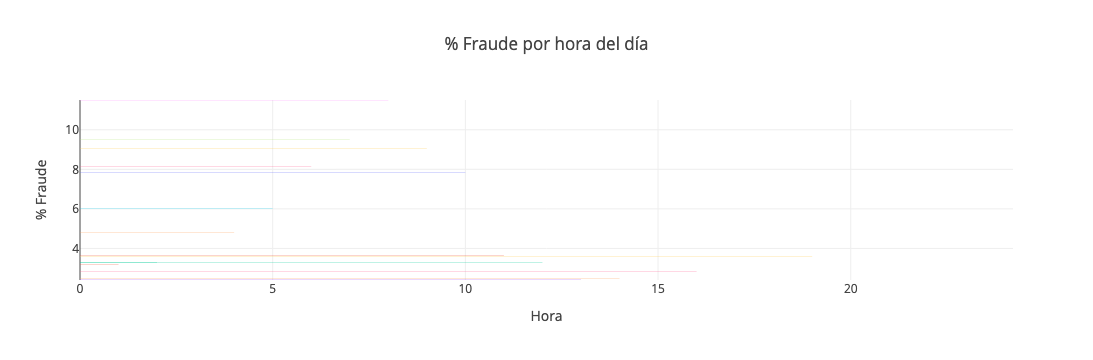

In [31]:
grafica_hora = px.bar(
    df_hora,
    x="transaction_hour",
    y="pct_fraude",
    color="pct_fraude",
    color_continuous_scale="Reds",
    title="% Fraude por hora del día",
    labels={"transaction_hour": "Hora", "pct_fraude": "% Fraude"}
)
grafica_hora.update_layout(template="gridon", showlegend=False)
grafica_hora.show()

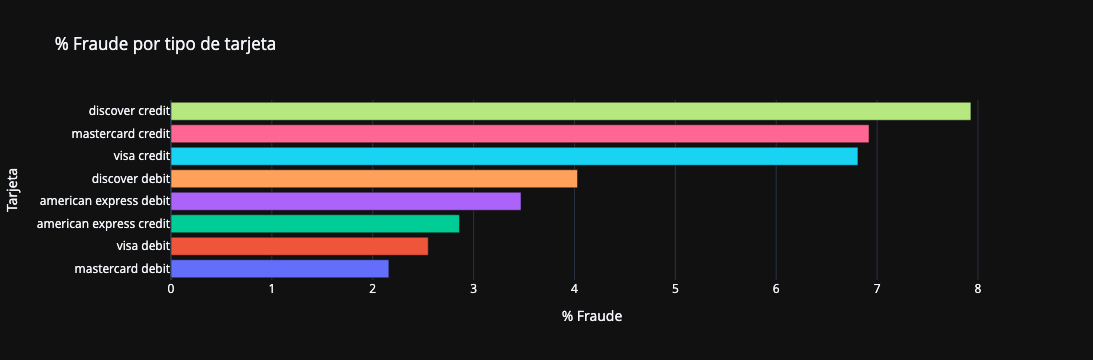

In [32]:
# Filtrar solo las combinaciones con volumen significativo
df_tarjeta_filtrado = df_tarjeta[df_tarjeta["total_transacciones"] > 100].copy()
df_tarjeta_filtrado["etiqueta"] = df_tarjeta_filtrado["red_tarjeta"] + " " + df_tarjeta_filtrado["tipo_tarjeta"]

fig_tarjeta = px.bar(
    df_tarjeta_filtrado.sort_values("pct_fraude", ascending=True),
    x="pct_fraude",
    y="etiqueta",
    orientation="h",
    color="pct_fraude",
    color_continuous_scale="Reds",
    title="% Fraude por tipo de tarjeta",
    labels={"pct_fraude": "% Fraude", "etiqueta": "Tarjeta"}
)
fig_tarjeta.update_layout(template="plotly_dark", showlegend=False)
fig_tarjeta.show()

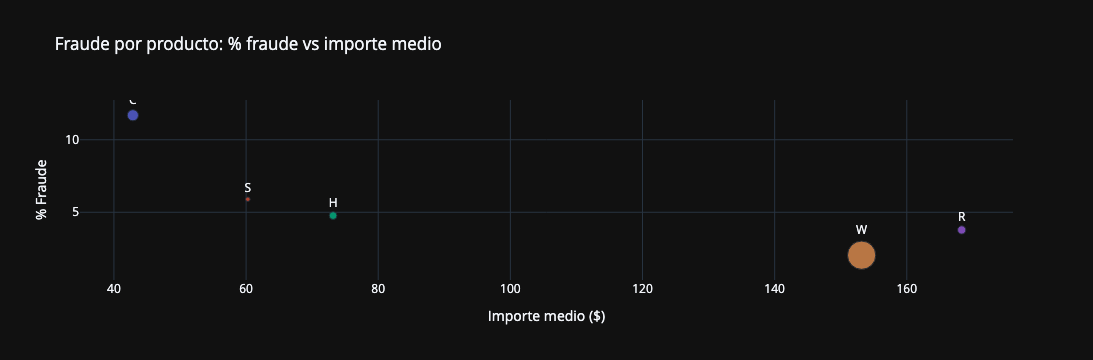

In [33]:
fig_producto = px.scatter(
    df_producto,
    x="importe_medio",
    y="pct_fraude",
    size="total_transacciones",
    color="pct_fraude",
    text="ProductCD",
    color_continuous_scale="Reds",
    title="Fraude por producto: % fraude vs importe medio",
    labels={"importe_medio": "Importe medio ($)", "pct_fraude": "% Fraude"}
)
fig_producto.update_traces(textposition="top center")
fig_producto.update_layout(template="plotly_dark", showlegend=False)
fig_producto.show()

In [34]:
spark_check = SparkSession.builder \
    .appName("check") \
    .master("local[*]") \
    .getOrCreate()
spark_check.sparkContext.setLogLevel("ERROR")

df_silver = spark_check.read.parquet(
    str(PROJECT_ROOT / "data/processed/silver/transactions_enriched")
)

print("Rango de fechas del dataset:")
df_silver.selectExpr(
    "min(transaction_date) as fecha_inicio",
    "max(transaction_date) as fecha_fin"
).show()

print("Transacciones por mes y año:")
from pyspark.sql import functions as F
df_silver.groupBy(
    F.year("transaction_date").alias("año"),
    F.month("transaction_date").alias("mes")
).count() \
 .orderBy("año", "mes") \
 .show(20)

spark_check.stop()

Rango de fechas del dataset:
+-------------------+-------------------+
|       fecha_inicio|          fecha_fin|
+-------------------+-------------------+
|2017-12-01 00:00:00|2018-06-01 00:58:51|
+-------------------+-------------------+

Transacciones por mes y año:
+----+---+------+
| año|mes| count|
+----+---+------+
|2017| 12|137321|
|2018|  1| 92585|
|2018|  2| 86021|
|2018|  3|101453|
|2018|  4| 83636|
|2018|  5| 89349|
|2018|  6|   175|
+----+---+------+



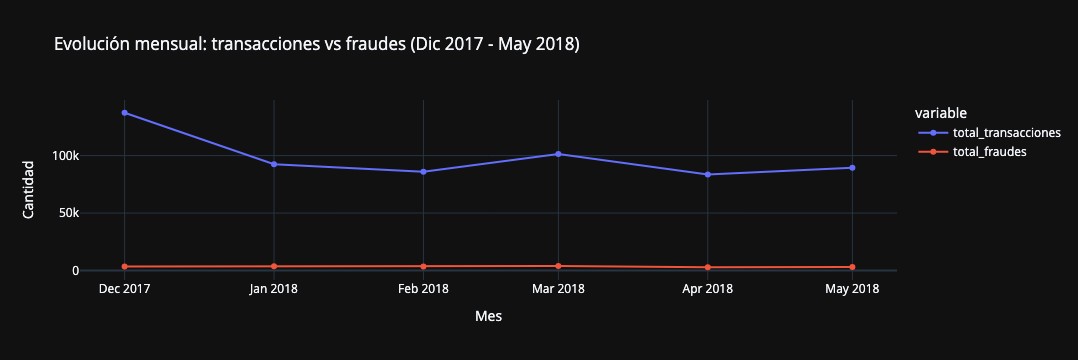

In [35]:

# Excluir junio (mes truncado con solo 175 transacciones)
df_mensual_filtrado = df_mensual[df_mensual["total_transacciones"] > 1000].copy()



fig_mensual = px.line(
    df_mensual,
    x="periodo",
    y=["total_transacciones", "total_fraudes"],
    title="Evolución mensual: transacciones vs fraudes (Dic 2017 - May 2018)",
    labels={"periodo": "Mes", "value": "Cantidad"},
    markers=True
)
fig_mensual.update_layout(template="plotly_dark")
fig_mensual.show()